In [1]:
import pandas as pd
import numpy as np


In [15]:
df = pd.read_csv('data/flight.csv')
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [16]:
cond = df['price'] >= 69265
df[cond]

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
206691,206691,Vistara,UK-809,Delhi,Evening,one,Morning,Mumbai,Business,12.42,1,74640
206692,206692,Vistara,UK-813,Delhi,Evening,one,Morning,Mumbai,Business,14.67,1,74640
206693,206693,Vistara,UK-809,Delhi,Evening,one,Night,Mumbai,Business,24.42,1,74640
206694,206694,Vistara,UK-809,Delhi,Evening,one,Night,Mumbai,Business,26.00,1,74640
206695,206695,Vistara,UK-813,Delhi,Evening,one,Night,Mumbai,Business,26.67,1,74640
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [17]:
cond = (df['days_left'] >= 10.08) & (df['price'] >= 69265)
df[cond]

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
207960,207960,Vistara,UK-737,Delhi,Afternoon,one,Night,Mumbai,Business,7.58,13,76953
208069,208069,Vistara,UK-747,Delhi,Early_Morning,one,Afternoon,Mumbai,Business,6.50,14,70793
208177,208177,Vistara,UK-747,Delhi,Early_Morning,one,Afternoon,Mumbai,Business,6.50,15,70793
208178,208178,Vistara,UK-811,Delhi,Early_Morning,one,Morning,Mumbai,Business,5.50,15,71056
208282,208282,Vistara,UK-747,Delhi,Early_Morning,one,Afternoon,Mumbai,Business,6.50,16,70793
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [18]:
# 클래스 점수 만들기
df['클래스점수'] = df['class'].map({
    'Economy': 1,
    'Business': 2
})

df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1


In [19]:
# days_left까지 반영한 가성비 점수
df['가성비'] = (df['클래스점수'] / (df['price'] * df['duration'] * df['days_left']) * 1000000).round(2)

df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1,77.41
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1,72.10
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1,77.37
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1,74.63
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1,72.07


In [20]:
# 가성비 순위
df['가성비순위'] = df['가성비'].rank(ascending=False, method='dense').astype(int)

df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1,77.41,63
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1,72.10,88
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1,77.37,66
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1,74.63,77
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1,72.07,90


In [21]:
df.sort_values(by='가성비순위')

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위
165567,165567,GO_FIRST,G8-806,Hyderabad,Afternoon,zero,Afternoon,Bangalore,Economy,1.25,1,4452,1,179.69,1
70309,70309,Indigo,6E-5217,Mumbai,Evening,zero,Evening,Hyderabad,Economy,1.33,1,4946,1,152.02,2
70308,70308,Indigo,6E-5208,Mumbai,Evening,zero,Evening,Hyderabad,Economy,1.42,1,4841,1,145.47,3
115604,115604,AirAsia,I5-1228,Bangalore,Early_Morning,zero,Morning,Chennai,Economy,1.00,2,3499,1,142.90,4
109654,109654,AirAsia,I5-1576,Bangalore,Early_Morning,zero,Morning,Hyderabad,Economy,1.17,1,6202,1,137.81,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295744,295744,Vistara,UK-822,Chennai,Morning,one,Afternoon,Bangalore,Business,30.25,46,58970,2,0.02,3043
261152,261152,Air_India,AI-610,Bangalore,Evening,one,Evening,Chennai,Business,47.75,47,55122,2,0.02,3043
255708,255708,Vistara,UK-814,Bangalore,Night,one,Evening,Kolkata,Business,22.42,45,80080,2,0.02,3043
260542,260542,Vistara,UK-867,Bangalore,Afternoon,two_or_more,Evening,Chennai,Business,31.17,35,75514,2,0.02,3043


In [22]:
df_price_top3 = df.sort_values(by='price', ascending=False).head(3)
df_price_top3

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위
261377,261377,Vistara,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.50,3,123071,2,0.40,3005
216096,216096,Vistara,UK-811,Delhi,Early_Morning,two_or_more,Evening,Kolkata,Business,10.92,5,117307,2,0.31,3014
215859,215859,Vistara,UK-809,Delhi,Evening,two_or_more,Evening,Kolkata,Business,21.08,1,116562,2,0.81,2964


In [23]:
cond = df['class'] == 'Business'
df[cond]

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위
206666,206666,Air_India,AI-868,Delhi,Evening,zero,Evening,Mumbai,Business,2.00,1,25612,2,39.04,366
206667,206667,Air_India,AI-624,Delhi,Evening,zero,Night,Mumbai,Business,2.25,1,25612,2,34.71,464
206668,206668,Air_India,AI-531,Delhi,Evening,one,Night,Mumbai,Business,24.75,1,42220,2,1.91,2854
206669,206669,Air_India,AI-839,Delhi,Night,one,Night,Mumbai,Business,26.50,1,44450,2,1.70,2875
206670,206670,Air_India,AI-544,Delhi,Evening,one,Night,Mumbai,Business,6.67,1,46690,2,6.42,2403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,2,0.06,3039
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,2,0.05,3040
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,2,0.04,3041
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,2,0.05,3040


In [25]:
subjects = ['price','days_left','가성비']
df_mean = df.groupby(by='destination_city')[subjects].mean()
df_mean

,price,days_left,가성비
destination_city,,,
Bangalore,21593.955784,26.048582,1.637205
Chennai,21953.323969,26.020437,1.496459
Delhi,18436.767870,26.178644,1.546151
Hyderabad,20427.661284,26.004166,1.805332
Kolkata,21959.557556,25.887633,1.084110
Mumbai,21372.529469,25.885967,1.534263


In [26]:
df['도시별 가성비 순위'] = df.groupby('destination_city')['가성비'].rank(ascending=False).astype(int)
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위,도시별 가성비 순위
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1,77.41,63,6
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1,72.10,88,17
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1,77.37,66,11
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1,74.63,77,15
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1,72.07,90,20


In [27]:
df_agg = df.groupby('destination_city')['가성비'].agg(['count','mean','max','min','median']).round(2)
df_agg

,count,mean,max,min,median
destination_city,,,,,
Bangalore,51068,1.64,179.69,0.02,0.50
Chennai,40368,1.50,142.90,0.02,0.44
Delhi,57360,1.55,80.90,0.03,0.69
Hyderabad,42726,1.81,152.02,0.02,0.46
Kolkata,49534,1.08,77.58,0.02,0.44
Mumbai,59097,1.53,119.78,0.02,0.54


In [28]:
df_std = df.groupby(by='destination_city')['가성비'].std().round(2)
df_std

destination_city
Bangalore    4.55
Chennai      4.34
Delhi        3.01
Hyderabad    5.22
Kolkata      2.54
Mumbai       3.49
Name: 가성비, dtype: float64

In [29]:
df['도시별 가성비 등급'] = pd.cut(df['가성비'], # 구간화할 데이터 평균
                bins=[0,50,60,70,80,90,100], #구간화할 점수 기준
                labels=['F','D','C','B','A','S'], #부여할 데이터
                right=True
                )

df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위,도시별 가성비 순위,도시별 가성비 등급
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1,77.41,63,6,B
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1,72.10,88,17,B
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1,77.37,66,11,B
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1,74.63,77,15,B
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1,72.07,90,20,B


In [30]:
df['가성비 분위등급'] = pd.qcut(df['가성비'], # 구간화할 데이터 평균
                        q=4, # 몇개 구간으로 나눌지 설정
                        labels=['하위','중하','중상','상위'] #부여할 데이터
                        )

df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위,도시별 가성비 순위,도시별 가성비 등급,가성비 분위등급
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1,77.41,63,6,B,상위
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1,72.10,88,17,B,상위
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1,77.37,66,11,B,상위
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1,74.63,77,15,B,상위
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1,72.07,90,20,B,상위


In [31]:
df['가성비 호불호'] = pd.cut(df['가성비'], # 구간화할 데이터 평균
                bins=[0,60,100], #구간화할 점수 기준
                labels=['불호','호'], #부여할 데이터
                right=True
                )
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위,도시별 가성비 순위,도시별 가성비 등급,가성비 분위등급,가성비 호불호
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1,77.41,63,6,B,상위,호
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1,72.10,88,17,B,상위,호
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1,77.37,66,11,B,상위,호
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1,74.63,77,15,B,상위,호
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1,72.07,90,20,B,상위,호


In [32]:
df['가성비 호불호'] = np.where(df['가성비']>=60, '호', '불호')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위,도시별 가성비 순위,도시별 가성비 등급,가성비 분위등급,가성비 호불호
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,1,77.41,63,6,B,상위,호
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,1,72.10,88,17,B,상위,호
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,1,77.37,66,11,B,상위,호
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,1,74.63,77,15,B,상위,호
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,1,72.07,90,20,B,상위,호


In [37]:
cond = (df['price'] >= 10000) & (df['가성비']>=70)
df_math = df[cond]
df_math

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,클래스점수,가성비,가성비순위,도시별 가성비 순위,도시별 가성비 등급,가성비 분위등급,가성비 호불호
109660,109660,Indigo,6E-6491,Bangalore,Afternoon,zero,Afternoon,Hyderabad,Economy,1.17,1,10638,1,80.34,55,19,A,상위,호
109664,109664,Indigo,6E-638,Bangalore,Evening,zero,Night,Hyderabad,Economy,1.08,1,12003,1,77.14,67,25,B,상위,호
165570,165570,AirAsia,I5-1518,Hyderabad,Evening,zero,Night,Bangalore,Economy,1.17,1,10300,1,82.98,47,17,A,상위,호
165571,165571,Indigo,6E-6319,Hyderabad,Evening,zero,Evening,Bangalore,Economy,1.25,1,10753,1,74.40,79,22,B,상위,호
165574,165574,Indigo,6E-285,Hyderabad,Evening,zero,Night,Bangalore,Economy,1.08,1,12118,1,76.41,70,20,B,상위,호
202655,202655,Indigo,6E-193,Chennai,Evening,zero,Night,Hyderabad,Economy,1.25,1,11027,1,72.55,82,31,B,상위,호
237998,237998,Air_India,AI-619,Mumbai,Night,zero,Night,Hyderabad,Business,1.33,1,19228,2,78.21,58,22,B,상위,호


In [39]:
df_pivot = pd.pivot_table(
            df, # 데이터 셋을 지정
            index = 'destination_city',
            columns= '도시별 가성비 등급',
            values= 'airline', #실제로 들어갈 집계할 데이터(유니크한 데이터)
            aggfunc='count',
            fill_value= 0, #만들어지지 않는 데이터이면 0으로 채움, 기본값은 NaN
            observed=False
        )
df_pivot

도시별 가성비 등급,F,D,C,B,A,S
destination_city,,,,,,
Bangalore,51013,19,12,5,3,4
Chennai,40329,12,9,2,7,1
Delhi,57337,7,4,11,1,0
Hyderabad,42644,27,15,19,8,3
Kolkata,49511,7,7,9,0,0
Mumbai,59056,10,9,18,1,0


In [41]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun gothic'
plt.rcParams['axes.unicode_minus'] = False 

In [58]:
df_destination_price = df.groupby('destination_city', as_index=False)['price'].mean().round(2)

df_destination_price.columns = ['목적도시', '평균가격']

df_destination_price

,목적도시,평균가격
0,Bangalore,21593.96
1,Chennai,21953.32
2,Delhi,18436.77
3,Hyderabad,20427.66
4,Kolkata,21959.56
5,Mumbai,21372.53


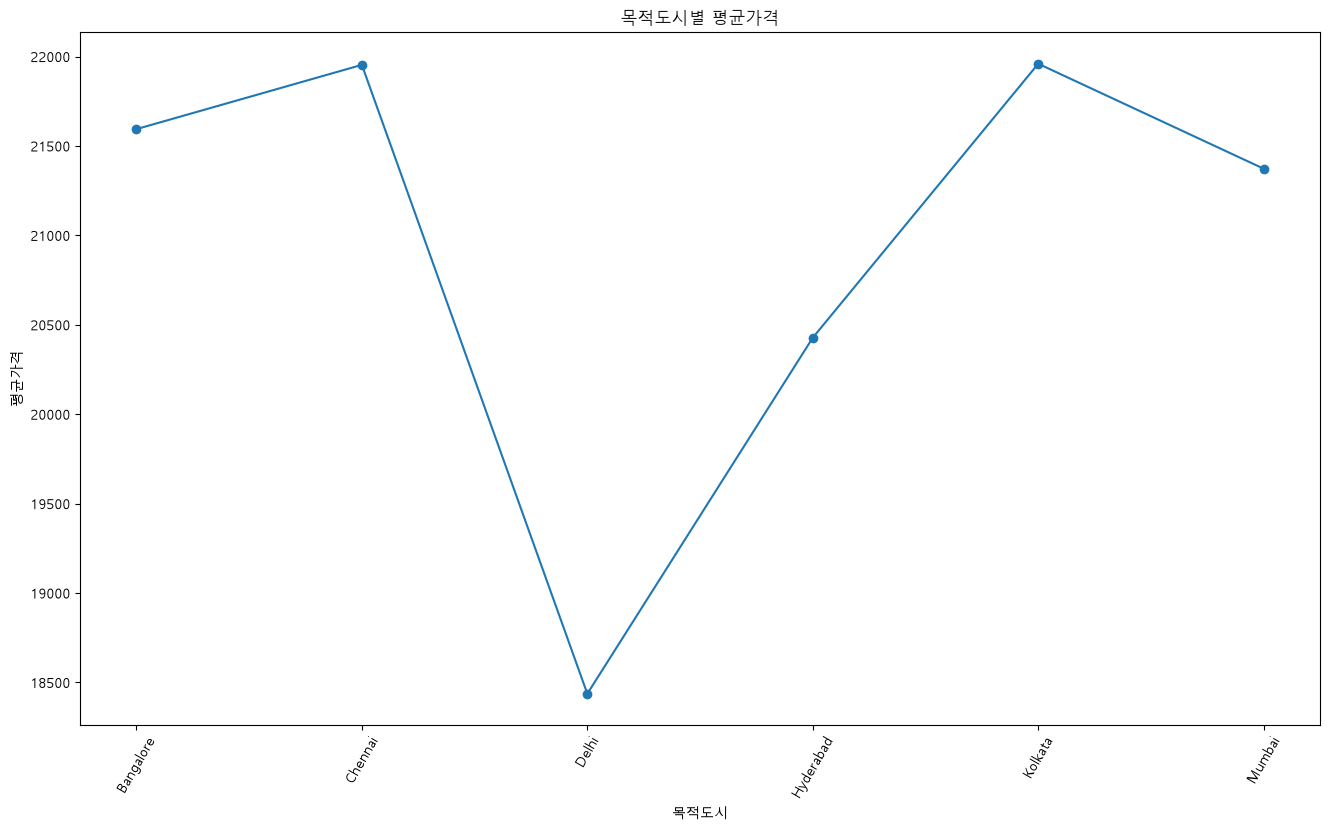

In [62]:
df_class1 = df_destination_price[['목적도시', '평균가격']]

plt.figure(figsize=(16, 9))

plt.plot(df_class1['목적도시'], df_class1['평균가격'], marker='o')

plt.title('목적도시별 평균가격')
plt.xlabel('목적도시')
plt.ylabel('평균가격')

plt.xticks(rotation=60)

plt.show()

In [63]:
df['클래스점수'] = df['class'].map({
    'Economy': 1,
    'Business': 2
})

# 가성비 점수 만들기
df['가성비점수'] = (df['클래스점수'] / (df['price'] * df['duration'] * df['days_left']) * 1000000).round(2)
# 목적도시별 price 평균 + 가성비점수 평균
df_destination_price = df.groupby('destination_city', as_index=False)[['price', '가성비점수']].mean().round(2)

# 컬럼명 변경
df_destination_price.columns = ['목적도시', '평균가격', '평균가성비점수']

df_destination_price

,목적도시,평균가격,평균가성비점수
0,Bangalore,21593.96,1.64
1,Chennai,21953.32,1.50
2,Delhi,18436.77,1.55
3,Hyderabad,20427.66,1.81
4,Kolkata,21959.56,1.08
5,Mumbai,21372.53,1.53


([<matplotlib.axis.XTick at 0x1d808041a90>,
 [Text(0.0, 0, 'Bangalore'),
  Text(1.0, 0, 'Chennai'),
  Text(2.0, 0, 'Delhi'),
  Text(3.0, 0, 'Hyderabad'),
  Text(4.0, 0, 'Kolkata'),
  Text(5.0, 0, 'Mumbai')])

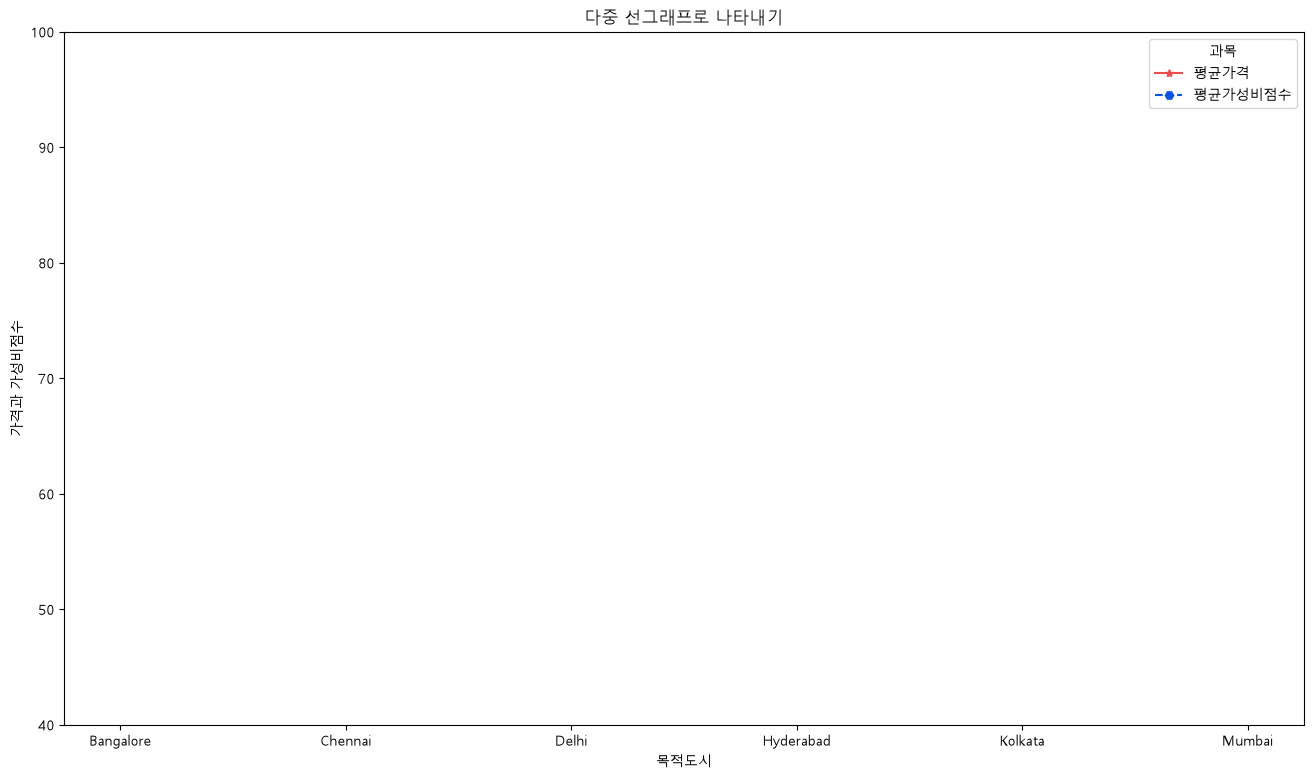

In [ ]:
df_class1 = df_destination_price[['목적도시', '평균가격','평균가성비점수']]

plt.figure(figsize=(16,9))

#캔바스에 여러개의 선그래프 그리기
#그래프 스타일 주기
#ls : line style (solid, dash, dash-dot, dot)
#marker : 상단 마크다운 표
# color : 색상주기
plt.plot(df_class1['목적도시'],df_class1['평균가격'],label='평균가격',ls='-', marker='*', color="#eb4e4e")
plt.plot(df_class1['목적도시'],df_class1['평균가성비점수'],label='평균가성비점수',ls='--', marker='H', color="#0b52eb")


plt.title('다중 선그래프로 나타내기')

plt.xlabel('목적도시')
plt.ylabel('가격과 가성비점수')
plt.ylim(40,100)
plt.legend(title='가격과 가성비점수') # 범주를 표시함
plt.xticks(df_class1['목적도시'])